In [25]:
import polars as pl
import json
import matplotlib.pyplot as plt

In [46]:
with open('simulacion_10_seeds_susceptibility.json', 'r') as f:
    resultados = json.load(f)

In [47]:
data = pl.DataFrame(resultados)

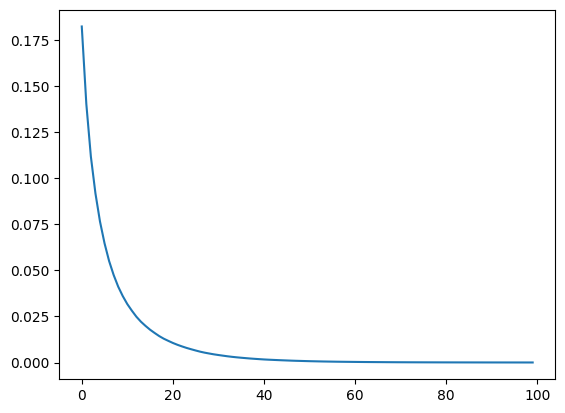

In [48]:
plt.plot(data.filter(pl.col('W_EMP_NEG').eq(1)
            & pl.col('W_NOR_NEG').eq(1)
            & pl.col('W_NOR_POS').eq(1/3)
            & pl.col('W_EMP_POS').eq(1/3))['suscept_history'][0])

In [ ]:
data = pl.DataFrame(resultados).with_columns(
    pl.col(['W_NOR_POS', 'W_NOR_NEG', 'W_EMP_POS', 'W_EMP_NEG']).round(2)
).write_csv('resultados_simulacion_optimizada_10_seeds.csv')

In [ ]:
data.with_columns(
    pl.col(['W_NOR_POS', 'W_NOR_NEG', 'W_EMP_POS', 'W_EMP_NEG']).round(2)
).write_csv('resultados_simulacion_optimizada_10_seeds.csv')

In [7]:
# data.with_columns(
#     pl.col('donaciones_delta').list.std().alias('donaciones_std'),
# ).sort('donaciones_std')

In [82]:
data.sort('W_NOR_NEG').sort(pl.col('W_NOR_POS'),descending=True).filter(pl.col('W_EMP_NEG').eq(0) & pl.col('W_EMP_POS').eq(0))

W_NOR_POS,W_NOR_NEG,W_EMP_POS,W_EMP_NEG,susceptibilidades,donaciones_delta,suscept_history
f64,f64,f64,f64,list[f64],list[f64],list[f64]
1.0,0.0,0.0,0.0,"[0.00061, 0.000973, … 0.5]","[0.081707, 0.138202, … 0.658118]","[0.259373, 0.266383, … 0.400537]"
1.0,0.333333,0.0,0.0,"[4.8680e-7, 0.000002, … 0.5]","[0.034051, 0.062855, … 0.663397]","[0.256391, 0.261237, … 0.386741]"
1.0,0.666667,0.0,0.0,"[4.4537e-11, 2.4189e-10, … 0.5]","[0.027198, 0.050146, … 0.66994]","[0.253409, 0.256179, … 0.371889]"
1.0,1.0,0.0,0.0,"[6.1825e-16, 1.1336e-14, … 0.5]","[0.021954, 0.042898, … 0.677173]","[0.250427, 0.251237, … 0.355258]"
0.666667,0.0,0.0,0.0,"[0.00059, 0.000932, … 0.5]","[0.081704, 0.138114, … 0.658435]","[0.257157, 0.262198, … 0.376576]"
…,…,…,…,…,…,…
0.333333,1.0,0.0,0.0,"[7.3186e-16, 1.3090e-14, … 0.5]","[0.021976, 0.042938, … 0.675209]","[0.245684, 0.242228, … 0.262489]"
0.0,0.0,0.0,0.0,"[0.000525, 0.000852, … 0.499236]","[0.081662, 0.137857, … 0.657869]","[0.251747, 0.251747, … 0.251747]"
0.0,0.333333,0.0,0.0,"[5.1009e-7, 0.000002, … 0.465213]","[0.034097, 0.062854, … 0.657431]","[0.248765, 0.246585, … 0.205766]"


In [ ]:
plt.hist(range)

In [131]:
def plot(plot_data: pl.DataFrame,variable:str,xlimits,ylimits,x_axis:str,file_name:str,condicion,variables_plot):    
    fig, ax = plt.subplots(figsize=(8, 8), ncols=4, nrows=4)
    
    plot_data = plot_data.filter(condicion).sort(variables_plot[0]).sort(pl.col(variables_plot[1]),descending=True)
        
    # flatten axes for easy indexing
    axes = ax.ravel()
    max_plots = axes.size

    # initialize local plot index and plot up to available subplots
    plot_idx = 0

    for row in plot_data.iter_rows(named=True):
        if plot_idx >= max_plots:
            break

        W_NOR_POS = float(row[variables_plot[0]])
        W_NOR_NEG = float(row[variables_plot[1]])
        variable_data = row[variable]
        
        make_title = lambda var_name: '$' + var_name.split('_')[0] + '^{' + var_name.split('_')[1].lower() + '}' + '_{' + var_name.split('_')[2].lower() + '}$'
        
        var_1_title = make_title(variables_plot[0])
        var_2_title = make_title(variables_plot[1])
        
        bins = [x/10 for x in range(0,11)]

        axes[plot_idx].hist(variable_data, bins=bins)
        # plot a vertical line at average donation delta
        avg_donacion = sum(variable_data) / len(variable_data)
        if variable=='donaciones_delta':            
            axes[plot_idx].axvline(avg_donacion, color='red', linestyle='dashed', linewidth=1)
            axes[plot_idx].text(avg_donacion + 0.02, ylimits * 0.9, f'{round(avg_donacion,2)}', color='red', fontsize=8)
            
        axes[plot_idx].set_title(f"{var_1_title}={round(W_NOR_POS,2)}\t{var_2_title}={round(W_NOR_NEG,2)}", fontsize=8)
        axes[plot_idx].set_xlim(0,xlimits)
        axes[plot_idx].set_ylim(0,ylimits)

        plot_idx += 1

    # turn off any unused subplots
    for i in range(plot_idx, max_plots):
        axes[i].axis('off')
        
    # add common x and y labels for the whole figure
    try:
        fig.supxlabel(x_axis, fontsize=12)
        fig.supylabel('Frecuencia (Número de jugadores)', fontsize=12)
    except AttributeError:
        # fallback for older matplotlib versions
        fig.text(0.5, 0.04, x_axis, ha='center', fontsize=12)
        fig.text(0.06, 0.5, 'Frecuencia (Número de jugadores)', va='center', rotation='vertical', fontsize=12)
    fig.subplots_adjust(bottom=0.08, left=0.12)

    plt.tight_layout()
    plt.savefig(f'imagenes/{file_name}.png')
    plt.close()

In [134]:
plot(plot_data=data,variable='donaciones_delta',xlimits=1,ylimits=510,x_axis='Porción de la dotación donada',file_name='donaciones_delta_emp_0',condicion=pl.col('W_EMP_NEG').eq(0) & pl.col('W_EMP_POS').eq(0),variables_plot=['W_NOR_NEG','W_NOR_POS'])
plot(plot_data=data, variable='susceptibilidades', xlimits=.5, ylimits=1100, x_axis='Susceptibilidades', file_name='susceptibilidades_emp_0',condicion=pl.col('W_EMP_NEG').eq(0) & pl.col('W_EMP_POS').eq(0),variables_plot=['W_NOR_NEG','W_NOR_POS'])

plot(plot_data=data,variable='donaciones_delta',xlimits=1,ylimits=510,x_axis='Porción de la dotación donada',file_name='donaciones_delta_nor_0',condicion=pl.col('W_NOR_NEG').eq(0) & pl.col('W_NOR_POS').eq(0),variables_plot=['W_EMP_NEG','W_EMP_POS'])
plot(plot_data=data, variable='susceptibilidades', xlimits=.5, ylimits=1100, x_axis='Susceptibilidades', file_name='susceptibilidades_nor_0',condicion=pl.col('W_NOR_NEG').eq(0) & pl.col('W_NOR_POS').eq(0),variables_plot=['W_EMP_NEG','W_EMP_POS'])

plot(plot_data=data,variable='donaciones_delta',xlimits=1,ylimits=510,x_axis='Porción de la dotación donada',file_name='donaciones_delta_emp_1',condicion=pl.col('W_EMP_NEG').eq(1) & pl.col('W_EMP_POS').eq(1),variables_plot=['W_NOR_NEG','W_NOR_POS'])
plot(plot_data=data, variable='susceptibilidades', xlimits=.5, ylimits=1100, x_axis='Susceptibilidades', file_name='susceptibilidades_emp_1',condicion=pl.col('W_EMP_NEG').eq(1) & pl.col('W_EMP_POS').eq(1),variables_plot=['W_NOR_NEG','W_NOR_POS'])

plot(plot_data=data,variable='donaciones_delta',xlimits=1,ylimits=510,x_axis='Porción de la dotación donada',file_name='donaciones_delta_nor_1',condicion=pl.col('W_NOR_NEG').eq(1) & pl.col('W_NOR_POS').eq(1),variables_plot=['W_EMP_NEG','W_EMP_POS'])
plot(plot_data=data, variable='susceptibilidades', xlimits=.5, ylimits=1100, x_axis='Susceptibilidades', file_name='susceptibilidades_nor_1',condicion=pl.col('W_NOR_NEG').eq(1) & pl.col('W_NOR_POS').eq(1),variables_plot=['W_EMP_NEG','W_EMP_POS'])

plot(plot_data=data,variable='donaciones_delta',xlimits=1,ylimits=510,x_axis='Porción de la dotación donada',file_name='donaciones_delta_final',condicion=pl.col('W_EMP_NEG').eq(1) & pl.col('W_NOR_NEG').eq(1),variables_plot=['W_NOR_POS','W_EMP_POS'])
plot(plot_data=data, variable='susceptibilidades', xlimits=.5, ylimits=1100, x_axis='Susceptibilidades', file_name='susceptibilidades_final',condicion=pl.col('W_EMP_NEG').eq(1) & pl.col('W_NOR_NEG').eq(1),variables_plot=['W_NOR_POS','W_EMP_POS'])

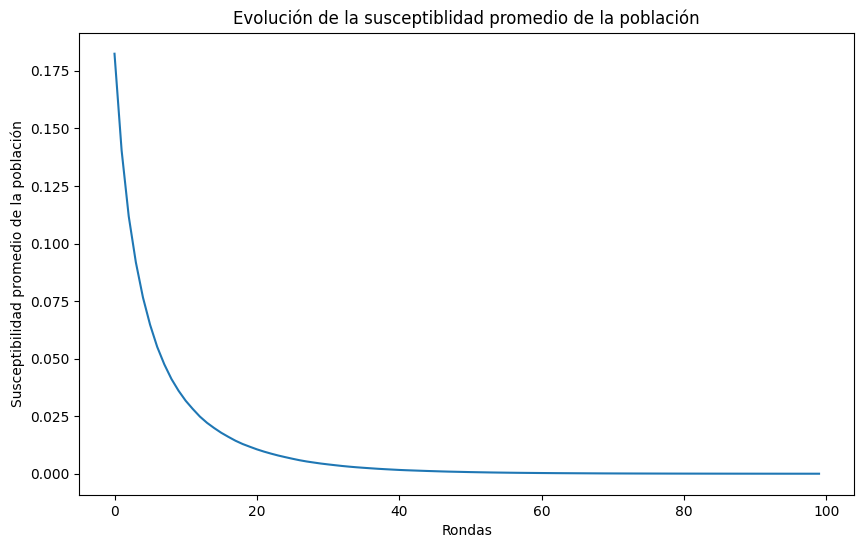

In [155]:
LR = data.filter(pl.col('W_EMP_NEG').eq(1) & pl.col('W_NOR_NEG').eq(1) & pl.col('W_NOR_POS').eq(1/3) & pl.col('W_EMP_POS').eq(1/3))['suscept_history'][0]

plt.figure(figsize=(10,6))
plt.plot(LR)
plt.title('Evolución de la susceptiblidad promedio de la población')
plt.xlabel('Rondas')
plt.ylabel('Susceptibilidad promedio de la población')
plt.savefig('imagenes/evolucion_susceptibilidad_promedio.png')